In [17]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_Nsgm as yu2

yu.setpath('analysis_Nsgm_lbd')

ens='b'
tfs=[8,10,12,14,16,18,20]

yunit_mul=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
[c2ptM,tf2c3ptM,c2ptCorrDic_NJN,tf2c3ptM_conn,tf2c3ptM_disc]=yu.load_pkl_reg('data_cd',pathlabel='processData')

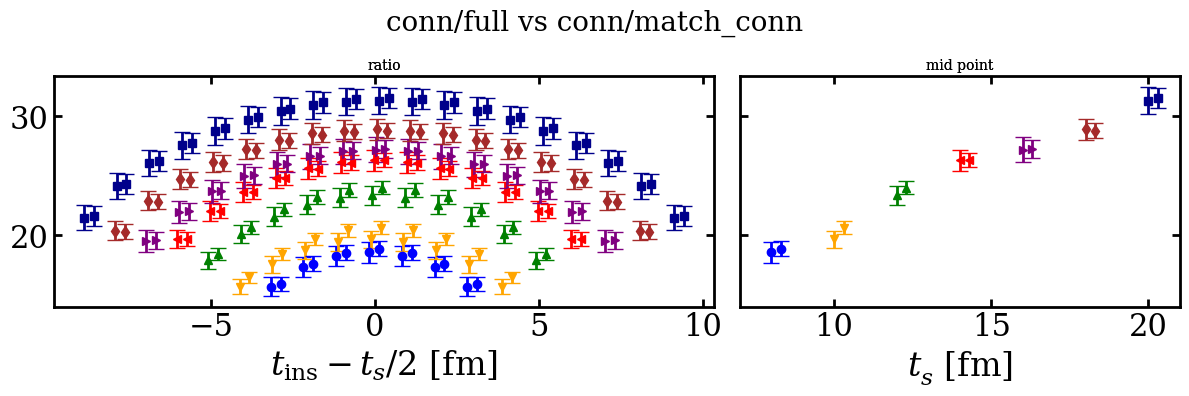

In [39]:
dic={'tf2ratio':{tf:np.real(tf2c3ptM_conn[tf][:,:,0,0])/c2ptM[:,tf:tf+1,0,0] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0,0,0],'yunit':yunit_mul}
dic2={'tf2ratio':{tf:np.real(tf2c3ptM_conn[tf][:,:,0,0])/c2ptCorrDic_NJN[tf][:,None] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0.3,0.3,0],'yunit':yunit_mul}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
fig,axs=yu.makePlot_3pt(dic2,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('conn/full vs conn/match_conn')
yu.finalizePlot()

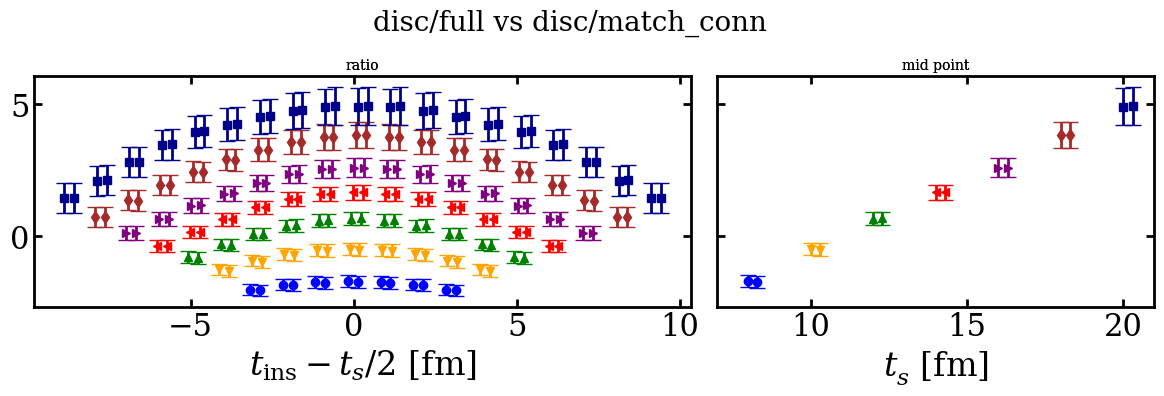

In [38]:
dic={'tf2ratio':{tf:np.real(tf2c3ptM_disc[tf][:,:,0,0])/c2ptM[:,tf:tf+1,0,0] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0,0,0],'yunit':yunit_mul}
dic2={'tf2ratio':{tf:np.real(tf2c3ptM_disc[tf][:,:,0,0])/c2ptCorrDic_NJN[tf][:,None] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0.3,0.3,0],'yunit':yunit_mul}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
fig,axs=yu.makePlot_3pt(dic2,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('disc/full vs disc/match_conn')
yu.finalizePlot()

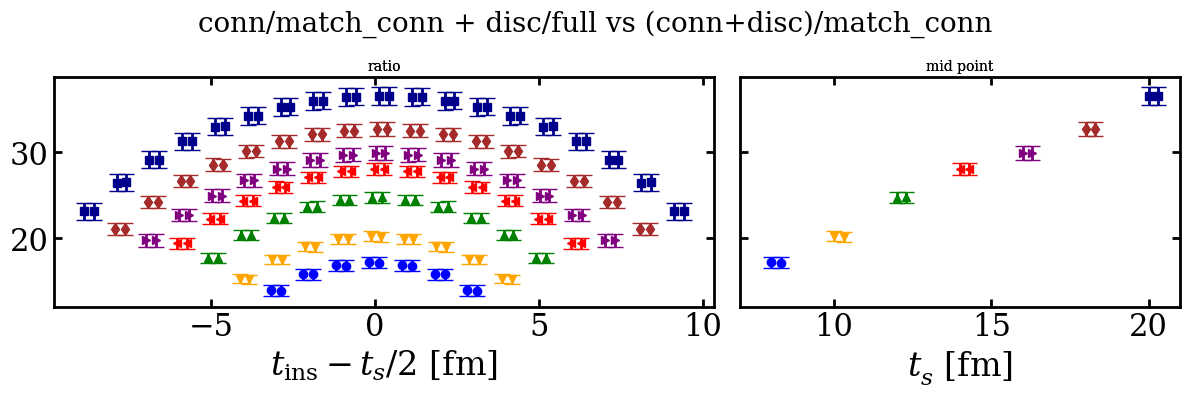

In [40]:
dic={'tf2ratio':{tf:np.real(tf2c3ptM_conn[tf][:,:,0,0])/c2ptCorrDic_NJN[tf][:,None] + np.real(tf2c3ptM_disc[tf][:,:,0,0])/c2ptM[:,tf:tf+1,0,0] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0,0,0],'yunit':yunit_mul}
dic2={'tf2ratio':{tf:np.real(tf2c3ptM[tf][:,:,0,0])/c2ptCorrDic_NJN[tf][:,None] for tf in tfs}, 'shift:[rainbow,midpoint,fit]':[0.3,0.3,0],'yunit':yunit_mul}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
fig,axs=yu.makePlot_3pt(dic2,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('conn/match_conn + disc/full vs (conn+disc)/match_conn')
yu.finalizePlot()